<a href="https://colab.research.google.com/github/Uche1000/1onwuchebi23001-/blob/main/pchembl_value_prediction_nnrti.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# A Practical Guide to Using Visual Studio Code and Python for Machine Learning in Small‑Molecule Drug Discovery, Design, and Optimization

## Purpose of This Guide

This guidebook provides a **step‑by‑step, end‑to‑end workflow** for applying Python‑based machine learning to **small‑molecule drug discovery** using **Visual Studio Code (VS Code)** as the primary development environment. It is designed for students, researchers, and professionals in medicinal chemistry, CADD, and pharmaceutical sciences.

The guide emphasizes **practical implementation**, reproducibility, and industry‑relevant best practices across:

* Data cleaning and curation
* Molecular descriptor calculation
* QSAR and ML model development
* Model validation and interpretation
* Bioactivity prediction and virtual screening
* Drug‑likeness and Lipinski filtering
* Visualization and reporting
* Deployment and reuse of models

**Author:** **ONWUKWE UCHECHUKWU EBIAKPO**

_Date:_ **3 February 2026_**


## Part 1: Environment Setup and Tooling

### 1.1 Installing Visual Studio Code

**Step 1: Install VS Code**

* Download VS Code for your OS
* Install and launch

**Step 2: Install Essential Extensions**

* Python (Microsoft)
* Jupyter
* Pylance
* autopep8

* Etc.

**Step 3: Verify Python Integration**


In [1]:
import sys
print(sys.executable)
print(sys.version)


/usr/bin/python3
3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


### 1.3 Installing Required Libraries
Python libraries are collections of pre-written code (modules and packages) that provide specific functionalities to perform common tasks, allowing researchers to avoid writing code from scratch. They significantly extend Python's capabilities in various domains such as data science, web development, and machine learning.

#### Core Python Libraries for Drug Discovery ML

* **Data handling**: pandas, numpy, scipy
* **Chemoinformatics**: RDKit, Mordred
* **ML frameworks**: scikit‑learn, XGBoost, LightGBM
* **Visualization**: matplotlib, seaborn, plotly
* **Deployment**: joblib, FastAPI

In [2]:
pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 62.2 MB/s eta 0:00:00


In [3]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.8 MB/s eta 0:00:00


In [4]:
# The start of a typical ML Script for regression data looks like this;
# ======================================================
# 1. IMPORT LIBRARIES
# ======================================================

# pandas: handles tabular data like Excel or CSV files
import pandas as pd

# rdkit: a chemical informatics library for molecule manipulation
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem
from rdkit.Avalon import pyAvalonTools

# numpy: numerical operations for arrays (used in fingerprints and ML)
import numpy as np

# scikit-learn: machine learning tools
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ML libraries for advanced models
from xgboost import XGBRegressor
from catboost import CatBoostRegressor, Pool
from lightgbm import LGBMRegressor

# Matplotlib for plotting and visualizations
import matplotlib.pyplot as plt

# joblib: save and load trained models
import joblib


## Part 2: Data Sources and Dataset Preparation

### 2.1 Common Data Sources

* ChEMBL
* PubChem
* BindingDB
* MMV Open Access Box
* In‑house or experimental datasets

### 2.2 Understanding Typical Drug Discovery Datasets

* SMILES strings
* Bioactivity values (IC50, EC50, Ki, pIC50)
* Assay metadata

### 2.3 Data Import and Inspection

* Loading CSV and excel files
* Initial sanity checks:

  * Missing values
  * Duplicates
  * Invalid SMILES

In [5]:
df = pd.read_csv('/content/sample_data/Train.csv')

In [6]:
# ===========================
# EXAMPLE: Loading and cleaning of Data.
# ===========================
from rdkit import Chem
import pandas as pd

# ===========================
# 2. LOAD & CLEAN TRAINING DATA
# ===========================

# Load training dataset
#df = pd.read_csv("Train.csv")

# Defensive column selection
required_cols = ["Smiles", "pChEMBL Value"]
df = df[required_cols + [c for c in df.columns if c not in required_cols]]

# Track initial size
initial_train_rows = df.shape[0]

# Drop missing critical values
df = df.dropna(subset=["Smiles", "pChEMBL Value"]).reset_index(drop=True)

# Ensure correct data types and normalize SMILES
df["Smiles"] = df["Smiles"].astype(str).str.strip()
df["pChEMBL Value"] = pd.to_numeric(df["pChEMBL Value"], errors="coerce")

# Drop rows that became invalid after coercion
df = df.dropna(subset=["pChEMBL Value"]).reset_index(drop=True)

# Remove duplicate SMILES (keep first occurrence)
df = df.drop_duplicates(subset=["Smiles"]).reset_index(drop=True)

# Validate SMILES with RDKit
def is_valid_smiles(smi):
    return Chem.MolFromSmiles(smi) is not None

df["valid_smiles"] = df["Smiles"].apply(is_valid_smiles)
df = df[df["valid_smiles"]].drop(columns="valid_smiles").reset_index(drop=True)

# Final report
print(
    f"Training dataset cleaned: "
    f"{initial_train_rows - df.shape[0]} rows removed, "
    f"{df.shape[0]} valid compounds remaining."
)


Training dataset cleaned: 3174 rows removed, 4777 valid compounds remaining.


## Part 3: Conversion of SMILES to Molecules
For most ML workflows, SMILES strings must be converted to an RDKit molecule object and subsequently to a fixed-length numerical representation (like a molecular fingerprint or descriptor vector) because most traditional machine learning models require inputs to be numerical and of a uniform size. Raw SMILES strings, being variable-length text sequences, do not inherently meet these criteria.

#### This conversion is neccessary because:
##### 1. Machine Learning Requires Numerical Input
##### 2. Fixed Input Length.
##### 3. Capturing Chemical Information.
##### 4. Data Validation and Standardization.


In [7]:
# EXAMPLE; Converting SMILES to Molecules

def smiles_to_mols(smiles_list):
    """
    Convert SMILES strings to RDKit molecule objects.
    Ignore invalid SMILES.
    """
    mols = []       # List to store valid molecules
    valid_idx = []  # Index of valid molecules
    for i, smi in enumerate(smiles_list):
        mol = Chem.MolFromSmiles(smi)  # Convert SMILES to molecule
        if mol:  # Only keep valid molecules
            mols.append(mol)
            valid_idx.append(i)
    return mols, valid_idx

## Part 4: Molecular Descriptor and Fingerprint Calculation
Molecular descriptors can be seen as numerical representations of molecular structures. Such descriptors are prerequisite for ML tasks.

### 4.1 Numerical Descriptor Types

* Physicochemical descriptors: Examples include Lipophilicity (logP), refractivity, Topological Polar Surface Area (TPSA), Solubility index etc.
* Topological descriptors: refer to descriptors that  take into account connectivity along with atom and bond labels.
* Constitutional descriptors: These descriptors only require atom and bond labels and usually represent counts of different types of atoms or bonds.Examples include atom counts, bond counts, and functional group counts.

### 4.2 Fingerprints: Traditionally, fingerprint descriptors are molecular representations in the form of bit strings. Examples include;

* ECFP (Morgan fingerprints)
* MACCS keys
* Avalon fingerprints

### CITATIONS: 1. Guha R, Willighagen E. A survey of quantitative descriptions of molecular structure. Curr Top Med Chem. 2012;12(18):1946-56. doi: 10.2174/156802612804910278. PMID: 23110530; PMCID: PMC3809149.
---

In [8]:
# EXAMPLE 4a: Calculating Fingerprints
def calculate_fingerprints(df, smiles_col='Smiles', method='ecfp', radius=2, nBits=1024):
    """
    Compute molecular fingerprints (ECFP or Avalon) for all molecules.
    Fingerprints are numeric representations of molecular structure.
    """
    smiles_list = df[smiles_col]
    mols, valid_idx = smiles_to_mols(smiles_list)
    fingerprints = []

    for mol in mols:
        # ECFP (Morgan) fingerprint
        if method == 'ecfp':
            fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits)
        # Avalon fingerprint
        elif method == 'avalon':
            fp = pyAvalonTools.GetAvalonFP(mol, nBits=nBits)
        else:
            raise ValueError("Method must be 'ecfp' or 'avalon'")

        # Convert fingerprint to numeric array
        fp_np = np.zeros((nBits,), dtype=np.uint8)
        DataStructs.ConvertToNumpyArray(fp, fp_np)
        fingerprints.append(fp_np)

    # Create DataFrame for fingerprints
    prefix = method.upper()
    fp_df = pd.DataFrame(fingerprints, columns=[f'{prefix}_{i}' for i in range(nBits)])
    fp_df.index = valid_idx

    # Keep only valid molecules
    df_valid = df.iloc[valid_idx].reset_index(drop=True)
    fp_df = fp_df.reset_index(drop=True)

    # Combine original data and fingerprint features
    return pd.concat([df_valid, fp_df], axis=1)


In [9]:
# EXAMPLE 4b: Calculating Fingerprints

# BEGIN ADDED CODE TO ENSURE 'df' IS DEFINED AND CLEANED (originally from cells 20c9dc1c and 6f3c0a14)
import pandas as pd
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem
from rdkit.Avalon import pyAvalonTools
import numpy as np

# Load training dataset
df = pd.read_csv("/content/sample_data/Train.csv")

# Defensive column selection
required_cols = ["Smiles", "pChEMBL Value"]
df = df[required_cols + [c for c in df.columns if c not in required_cols]]

# Track initial size
initial_train_rows = df.shape[0]

# Drop missing critical values
df = df.dropna(subset=["Smiles", "pChEMBL Value"]).reset_index(drop=True)

# Ensure correct data types and normalize SMILES
df["Smiles"] = df["Smiles"].astype(str).str.strip()
df["pChEMBL Value"] = pd.to_numeric(df["pChEMBL Value"], errors="coerce")

# Drop rows that became invalid after coercion
df = df.dropna(subset=["pChEMBL Value"]).reset_index(drop=True)

# Remove duplicate SMILES (keep first occurrence)
df = df.drop_duplicates(subset=["Smiles"]).reset_index(drop=True)

# Validate SMILES with RDKit
def is_valid_smiles(smi):
    return Chem.MolFromSmiles(smi) is not None

df["valid_smiles"] = df["Smiles"].apply(is_valid_smiles)
df = df[df["valid_smiles"]].drop(columns="valid_smiles").reset_index(drop=True)

# Final report (modified to indicate in-cell definition)
print(
    f"[FIXED CELL FB82EDFD] Training dataset cleaned: "
    f"{initial_train_rows - df.shape[0]} rows removed, "
    f"{df.shape[0]} valid compounds remaining."
)
# END ADDED CODE

# The calculate_fingerprints function also needs to be defined if not already in global scope
def smiles_to_mols(smiles_list):
    """
    Convert SMILES strings to RDKit molecule objects.
    Ignore invalid SMILES.
    """
    mols = []       # List to store valid molecules
    valid_idx = []  # Index of valid molecules
    for i, smi in enumerate(smiles_list):
        mol = Chem.MolFromSmiles(smi)  # Convert SMILES to molecule
        if mol:  # Only keep valid molecules
            mols.append(mol)
            valid_idx.append(i)
    return mols, valid_idx

def calculate_fingerprints(df, smiles_col='Smiles', method='ecfp', radius=2, nBits=1024):
    """
    Compute molecular fingerprints (ECFP or Avalon) for all molecules.
    Fingerprints are numeric representations of molecular structure.
    """
    smiles_list = df[smiles_col]
    mols, valid_idx = smiles_to_mols(smiles_list)
    fingerprints = []

    for mol in mols:
        # ECFP (Morgan) fingerprint
        if method == 'ecfp':
            fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits)
        # Avalon fingerprint
        elif method == 'avalon':
            fp = pyAvalonTools.GetAvalonFP(mol, nBits=nBits)
        else:
            raise ValueError("Method must be 'ecfp' or 'avalon'")

        # Convert fingerprint to numeric array
        fp_np = np.zeros((nBits,), dtype=np.uint8)
        DataStructs.ConvertToNumpyArray(fp, fp_np)
        fingerprints.append(fp_np)

    # Create DataFrame for fingerprints
    prefix = method.upper()
    fp_df = pd.DataFrame(fingerprints, columns=[f'{prefix}_{i}' for i in range(nBits)])
    fp_df.index = valid_idx

    # Keep only valid molecules
    df_valid = df.iloc[valid_idx].reset_index(drop=True)
    fp_df = fp_df.reset_index(drop=True)

    # Combine original data and fingerprint features
    return pd.concat([df_valid, fp_df], axis=1)

df_with_ecfp = calculate_fingerprints(df, smiles_col='Smiles', method='ecfp', radius=2, nBits=1024)

# Define features (X) and target (y)
X = df_with_ecfp.drop(columns=['Smiles', 'pChEMBL Value', 'ChEMBL ID'])
y = df_with_ecfp['pChEMBL Value']

# Remove constant columns
X = X.loc[:, X.nunique() > 1]

[FIXED CELL FB82EDFD] Training dataset cleaned: 3174 rows removed, 4777 valid compounds remaining.


[08:48:31] DEPRECATION WARNING: please use MorganGenerator
[08:48:31] DEPRECATION WARNING: please use MorganGenerator
[08:48:31] DEPRECATION WARNING: please use MorganGenerator
[08:48:31] DEPRECATION WARNING: please use MorganGenerator
[08:48:31] DEPRECATION WARNING: please use MorganGenerator
[08:48:31] DEPRECATION WARNING: please use MorganGenerator
[08:48:31] DEPRECATION WARNING: please use MorganGenerator
[08:48:31] DEPRECATION WARNING: please use MorganGenerator
[08:48:31] DEPRECATION WARNING: please use MorganGenerator
[08:48:31] DEPRECATION WARNING: please use MorganGenerator
[08:48:31] DEPRECATION WARNING: please use MorganGenerator
[08:48:31] DEPRECATION WARNING: please use MorganGenerator
[08:48:31] DEPRECATION WARNING: please use MorganGenerator
[08:48:31] DEPRECATION WARNING: please use MorganGenerator
[08:48:31] DEPRECATION WARNING: please use MorganGenerator
[08:48:31] DEPRECATION WARNING: please use MorganGenerator
[08:48:31] DEPRECATION WARNING: please use MorganGenerat

## Part 5: Machine Learning Model Development
Machine learning models are broadly categorized into four primary types based on their learning approach: supervised learning, unsupervised learning, semi-supervised learning, and reinforcement learning.

### 1. Supervised Learning
In supervised learning, models are trained on a labeled dataset, which means the training data includes both input examples and their corresponding correct outputs (labels). Types include;

##### Classification: Predicts categorical or labelled outputs (e.g., classifying an email as "spam" or "not spam", or an molecule as a "Active" or "Not Active").
Common algorithms: Logistic regression, Naive Bayes, Random Forests and Support Vector Machines (SVM).

##### Regression: Predicts continuous, numerical outputs (e.g.,  predicting temperature or pIC50 values).
Common algorithms: Linear regression, Random Forest, Gradient Boosting, Lasso regression, and LightGBM.

### 2. Unsupervised Learning
Unsupervised learning models work with unlabeled data and are tasked with finding hidden patterns, structures, or relationships within the data on their own, without human guidance or a "correct" answer key. Types include;

##### Clustering: Groups similar data points into clusters based on shared characteristics (e.g., customer segmentation for targeted marketing).
Common algorithms: K-Means clustering, Hierarchical clustering, Mean-Shift, and DBSCAN.

##### Dimensionality Reduction: Simplifies complex datasets by reducing the number of variables while retaining important information, often for data visualization or preprocessing.
Common techniques: Principal Component Analysis (PCA) and t-Distributed Stochastic Neighbor Embedding (t-SNE).

##### Association: Discovers rules or correlations between different items in large databases (e.g., Diabetes comorbidity with hypertension studies or market basket analysis to find products often bought together).
Common algorithms: Apriori and FP-Growth.

### 3. Semi-Supervised Learning
This approach combines a small amount of labeled data with a large amount of unlabeled data.
Common techniques: Self-training, and Generative Adversarial Networks (GANs).

### 4. Reinforcement Learning
Reinforcement learning trains a model to make a sequence of decisions by interacting with an environment and receiving feedback in the form of rewards or penalties. The model learns through trial and error to identify the optimal strategy or "policy" to maximize the cumulative reward.

Applications: Training agents to play games (like AlphaGo), robotics and automation, and autonomous vehicles.
Common algorithms: Q-learning and Policy Gradient methods.

## IMPLEMENTATION
### 6.1 Problem Framing: Define the ML problem statement, For example

* Regression (QSAR): Prediction of a continuos numerical variables, e.g pIC50, Docking scores, etc.

* Classification: Predicts categories or labels. For example 'Active vs Inactive', 'Healthy vs Unhealthy', 'Inhibitor vs Non-inhibitor'. The condition that is desired is typically assigned '1' and the condition that is not desired '0'.

### 5.2 Train–Validation–Test Splits
Training Set: Used to fit model parameters. Here model learns relationships between molecular descriptors and bioactivity. It should be the largest portion of the data.

Validation Set: Used to tune hyperparameters, it guides model selection (e.g., RF vs XGBoost) and prevents overfitting during optimization.

Test Set: Used once, at the very end of the model development, it provides an unbiased estimate of real-world performance. This dataset must remain completely untouched during model development

NB: Cross-validation within the training set can also be used for hyperparameter optimization

## SUMMARY
### 5.3 Baseline Models

* Linear Regression
* Ridge / Lasso
* k‑Nearest Neighbors

### 5.4 Tree‑Based and Ensemble Models

* Random Forest
* Gradient Boosting
* XGBoost
* LightGBM

### 5.5 Hyperparameter Optimization

* Grid search
* Randomized search
* Cross‑validation strategies

#### CITATION: Katrina Wakefield, A guide to the types of machine learning algorithims and their applications, SAS UK, https://www.sas.com/en_gb/insights/articles/analytics/machine-learning-algorithms.html#:~:text=At%20its%20most%20basic%2C%20machine,%2Dsupervised%2C%20unsupervised%20and%20reinforcement.


In [10]:
from sklearn.preprocessing import StandardScaler

X_standardized = StandardScaler().fit_transform(X)

In [11]:
# To prevent distortion of X_train1 for test data prediction
from sklearn.model_selection import train_test_split

X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# 80% training, 20% testing

In [12]:
# EXAMPLE 5A: Spilitting Data

X_train, X_test, y_train, y_test = train_test_split(
    X_standardized, y, test_size=0.2, random_state=42
)
# 80% training, 20% testing


In [13]:
# EXAMPLE 5B: Defining Models

models = {
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42),
    "GradBoost": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "AdaBoost": AdaBoostRegressor(n_estimators=100, random_state=42),
    "HistGradientBoosting": HistGradientBoostingRegressor(max_iter=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42, verbosity=0),
    "CatBoost": CatBoostRegressor(n_estimators=100, random_state=42, verbose=0),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
}


In [14]:
#EXAMPLE 5C: Train Models

results = []

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)        # Train model
    y_pred = model.predict(X_test)     # Predict on test set

    # Calculate evaluation metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append([name, mae, mse, rmse, r2])

Training RandomForest...
Training GradBoost...
Training AdaBoost...
Training HistGradientBoosting...
Training XGBoost...
Training CatBoost...
Training LightGBM...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.038919 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2781
[LightGBM] [Info] Number of data points in the train set: 3821, number of used features: 927
[LightGBM] [Info] Start training from score 6.234033


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


## Part 6: Model Evaluation and Validation

### 6.1 Regression Metrics

#### Error Metrics (Lower is Better)
* Mean Absolute Error (MAE): Average of absolute differences between predictions and actual values. Easy to interpret, treats all errors equally, robust to outliers.

* Mean Squared Error (MSE): Average of squared differences. Penalizes large errors more significantly, veyry useful when big mistakes are costly.

* Root Mean Squared Error (RMSE): Square root of MSE. Same units as the target variable, making it more interpretable than MSE while still penalizing large errors.

#### Model Fit Metric (Higher is Better, typically 0-1)
R-Squared (R²): Coefficient of determination, representing the proportion of variance in the dependent variable explained by the model. A value closer to 1 means lower variability.

### 6.2 Classification Metrics
True Positive (TP): Correctly predicted positive.
False Positive (FP): Incorrectly predicted positive (Type I error).
False Negative (FN): Incorrectly predicted negative (Type II error).
True Negative (TN): Correctly predicted negative.

* Accuracy: Overall correctness

* Precision: Of all predicted positives, how many were correct? (Minimizes false positives).

* Recall:  Of all actual positives, how many did the model find? (Minimizes false negatives).

* F1 Score: Harmonic mean of Precision and Recall; balances both, better for imbalanced data


###### CITATION AND FURTHER READING: scikit-learn, Metrics and scoring: quantifying the quality of predictions, User Guide, Model Selection and Evaluation, https://scikit-learn.org/stable/modules/model_evaluation.html

In [15]:
# EXAMPLE 6: Evaluating Models
# Convert results to DataFrame for comparison
results_df = pd.DataFrame(results, columns=["Model","MAE","MSE","RMSE","R2"])
results_df = results_df.sort_values("RMSE").reset_index(drop=True)
results_df["Rank"] = results_df["RMSE"].rank(method="first")
print("\nTop Models Ranked by RMSE:")
print(results_df)


Top Models Ranked by RMSE:
                  Model       MAE       MSE      RMSE        R2  Rank
0          RandomForest  0.533495  0.509497  0.713791  0.636536   1.0
1               XGBoost  0.563904  0.565834  0.752219  0.596347   2.0
2  HistGradientBoosting  0.572888  0.566079  0.752382  0.596172   3.0
3              LightGBM  0.572888  0.566079  0.752382  0.596172   4.0
4              CatBoost  0.573720  0.582532  0.763238  0.584434   5.0
5             GradBoost  0.689446  0.757356  0.870262  0.459719   6.0
6              AdaBoost  0.916057  1.216208  1.102818  0.132384   7.0


In [16]:
# Split data
X_train, X_val, y_train, y_val = train_test_split(X_standardized, y, test_size=0.2)

model = XGBRegressor(
    n_estimators=2000,          # Set high
    learning_rate=0.01,
    early_stopping_rounds=50,   # Stop if no improvement
    eval_metric=['rmse', 'mae']
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=100                  # Print every 100 trees
)

[0]	validation_0-rmse:1.15859	validation_0-mae:0.96907
[100]	validation_0-rmse:0.94191	validation_0-mae:0.77601
[200]	validation_0-rmse:0.85950	validation_0-mae:0.69661
[300]	validation_0-rmse:0.82532	validation_0-mae:0.66160
[400]	validation_0-rmse:0.80306	validation_0-mae:0.64098
[500]	validation_0-rmse:0.78819	validation_0-mae:0.62619
[600]	validation_0-rmse:0.77833	validation_0-mae:0.61511
[700]	validation_0-rmse:0.77110	validation_0-mae:0.60621
[800]	validation_0-rmse:0.76383	validation_0-mae:0.59723
[900]	validation_0-rmse:0.75747	validation_0-mae:0.58978
[1000]	validation_0-rmse:0.75198	validation_0-mae:0.58359
[1100]	validation_0-rmse:0.74741	validation_0-mae:0.57840
[1200]	validation_0-rmse:0.74306	validation_0-mae:0.57348
[1300]	validation_0-rmse:0.73862	validation_0-mae:0.56871
[1400]	validation_0-rmse:0.73507	validation_0-mae:0.56470
[1500]	validation_0-rmse:0.73186	validation_0-mae:0.56067
[1600]	validation_0-rmse:0.72891	validation_0-mae:0.55726
[1700]	validation_0-rmse:0

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=50,
             enable_categorical=False, eval_metric=['rmse', 'mae'],
             feature_types=None, feature_weights=None, gamma=None,
             grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.01, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=2000, n_jobs=None,
             num_parallel_tree=None, ...)

In [17]:
# EXAMPLE 6C: Predict test set and evaluate metrics
pred_y_test = model.predict(X_test)

# Evaluation metrics
rmse = np.sqrt(mean_squared_error(y_test, pred_y_test))
mae = mean_absolute_error(y_test, pred_y_test)
r2 = r2_score(y_test, pred_y_test)
print("Random Forest Tuned Model:")
print("RMSE:", rmse, "MAE:", mae, "R2:", r2)

Random Forest Tuned Model:
RMSE: 0.5412332973935773 MAE: 0.3999653883858206 R2: 0.7910276225844578


In [18]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

kf = KFold(n_splits=5, shuffle=True, random_state=42)

rmse_scores = []

for train_idx, val_idx in kf.split(X_train):
    X_tr, X_val_fold = X_train[train_idx], X_train[val_idx]
    y_tr, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]

    model = CatBoostRegressor(
        iterations=3000,
        learning_rate=0.03,
        depth=8,
        loss_function='RMSE',
        eval_metric='RMSE',
        l2_leaf_reg=5,
        random_strength=1.0,
        bagging_temperature=0.5,
        subsample=0.8,
        rsm=0.8,
        early_stopping_rounds=200,
        grow_policy='SymmetricTree',
        random_seed=42,
        verbose=0 # Set to 0 to suppress verbose output during CV
    )

    model.fit(
        X_tr, y_tr,
        eval_set=(X_val_fold, y_val_fold),
        early_stopping_rounds=200,
        verbose=0
    )

    preds = model.predict(X_val_fold)
    rmse = np.sqrt(mean_squared_error(y_val_fold, preds))
    rmse_scores.append(rmse)

print(np.mean(rmse_scores), np.std(rmse_scores))

0.7351268463204997 0.031228944746937656


In [19]:
# EXAMPLE 6C: Predict test set and evaluate metrics
pred_y_test = model.predict(X_test)

# Evaluation metrics
rmse = np.sqrt(mean_squared_error(y_test, pred_y_test))
mae = mean_absolute_error(y_test, pred_y_test)
r2 = r2_score(y_test, pred_y_test)
print("Random Forest Tuned Model:")
print("RMSE:", rmse, "MAE:", mae, "R2:", r2)

Random Forest Tuned Model:
RMSE: 0.5262223357390173 MAE: 0.3649787565309003 R2: 0.8024584644905209


In [20]:
# ================================
# 2. MODEL CONFIGURATION
# ================================
def get_model():
    return XGBRegressor(
        n_estimators=2000,
        learning_rate=0.01,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        reg_alpha=0.1,
        early_stopping_rounds=50,
        eval_metric="rmse",
        random_state=42,
        verbosity=0
    )

# ================================
# 3. CROSS-VALIDATION (WITH EARLY STOPPING)
# ================================
kf = KFold(n_splits=5, shuffle=True, random_state=42)

rmse_scores = []
mae_scores = []
r2_scores = []
best_iterations = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
    print(f"\n🔁 Fold {fold+1}")

    X_tr, X_val = X_train[train_idx], X_train[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx] # Fixed: Use .iloc for positional indexing

    model = get_model()

    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    preds = model.predict(X_val)

    rmse = np.sqrt(mean_squared_error(y_val, preds))
    mae = mean_absolute_error(y_val, preds)
    r2 = r2_score(y_val, preds)

    rmse_scores.append(rmse)
    mae_scores.append(mae)
    r2_scores.append(r2)
    best_iterations.append(model.best_iteration)

    print(f"RMSE: {rmse:.4f} | MAE: {mae:.4f} | R2: {r2:.4f} | Best Iter: {model.best_iteration}")

# ================================
# 4. CV SUMMARY
# ================================
print("\n📊 Cross-Validation Summary (5-Fold):")
print(f"RMSE: {np.mean(rmse_scores):.4f} ± {np.std(rmse_scores):.4f}")
print(f"MAE:  {np.mean(mae_scores):.4f} ± {np.std(mae_scores):.4f}")
print(f"R2:   {np.mean(r2_scores):.4f} ± {np.std(r2_scores):.4f}")
print(f"Avg Best Iteration: {int(np.mean(best_iterations))}")

# ================================
# 5. FINAL MODEL TRAINING
# ================================
final_model = get_model()

# Use X_test and y_test as the holdout set for final evaluation
final_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)], # Fixed: Use X_test, y_test instead of undefined X_holdout, y_holdout
    verbose=100
)

# ================================
# 6. HOLDOUT EVALUATION
# ================================
final_preds = final_model.predict(X_test) # Fixed: Use X_test

final_rmse = np.sqrt(mean_squared_error(y_test, final_preds)) # Fixed: Use y_test
final_mae = mean_absolute_error(y_test, final_preds) # Fixed: Use y_test
final_r2 = r2_score(y_test, final_preds) # Fixed: Use y_test

print("\n🎯 Final Holdout Performance:")
print(f"RMSE: {final_rmse:.4f}")
print(f"MAE:  {final_mae:.4f}")
print(f"R2:   {final_r2:.4f}")

print(f"\n✅ Best Iteration (Final Model): {final_model.best_iteration}")



🔁 Fold 1
RMSE: 0.6903 | MAE: 0.5259 | R2: 0.6482 | Best Iter: 1999

🔁 Fold 2
RMSE: 0.7483 | MAE: 0.5636 | R2: 0.5767 | Best Iter: 1999

🔁 Fold 3
RMSE: 0.7607 | MAE: 0.5682 | R2: 0.6097 | Best Iter: 1981

🔁 Fold 4
RMSE: 0.7555 | MAE: 0.5823 | R2: 0.6074 | Best Iter: 1997

🔁 Fold 5
RMSE: 0.7798 | MAE: 0.5885 | R2: 0.5881 | Best Iter: 1999

📊 Cross-Validation Summary (5-Fold):
RMSE: 0.7469 ± 0.0302
MAE:  0.5657 ± 0.0219
R2:   0.6060 ± 0.0244
Avg Best Iteration: 1995
[0]	validation_0-rmse:1.18044
[100]	validation_0-rmse:0.93842
[200]	validation_0-rmse:0.82928
[300]	validation_0-rmse:0.77482
[400]	validation_0-rmse:0.73748
[500]	validation_0-rmse:0.70914
[600]	validation_0-rmse:0.68583
[700]	validation_0-rmse:0.66373
[800]	validation_0-rmse:0.64568
[900]	validation_0-rmse:0.62929
[1000]	validation_0-rmse:0.61476
[1100]	validation_0-rmse:0.60066
[1200]	validation_0-rmse:0.58783
[1300]	validation_0-rmse:0.57661
[1400]	validation_0-rmse:0.56665
[1500]	validation_0-rmse:0.55740
[1600]	validati

In [21]:
from lightgbm import LGBMRegressor
import lightgbm as lgb # Added import for lgb alias
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error


# ================================
# 2. MODEL CONFIGURATION
# ================================
def get_model():
    return LGBMRegressor(
        n_estimators=5000,          # large, rely on early stopping
        learning_rate=0.01,
        max_depth=-1,               # let LightGBM decide
        num_leaves=31,              # key parameter!

        subsample=0.8,
        colsample_bytree=0.8,

        reg_lambda=1.0,
        reg_alpha=0.1,

        random_state=42,
        n_jobs=-1
    )

# ================================
# 3. CROSS-VALIDATION (WITH EARLY STOPPING)
# ================================
kf = KFold(n_splits=5, shuffle=True, random_state=42)

rmse_scores = []
mae_scores = []
r2_scores = []
best_iterations = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
    print(f"\n🔁 Fold {fold+1}")

    X_tr, X_val = X_train[train_idx], X_train[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx] # Fixed: Use .iloc for positional indexing

    model = get_model()

    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        eval_metric="rmse",
        callbacks=[
            # Early stopping
            lgb.early_stopping(stopping_rounds=100, verbose=False)
        ]
    )

    preds = model.predict(X_val)

    rmse = np.sqrt(mean_squared_error(y_val, preds)) # Fixed: Use np.sqrt
    mae = mean_absolute_error(y_val, preds)
    r2 = r2_score(y_val, preds)

    rmse_scores.append(rmse)
    mae_scores.append(mae)
    r2_scores.append(r2)
    best_iterations.append(model.best_iteration_)

    print(f"RMSE: {rmse:.4f} | MAE: {mae:.4f} | R2: {r2:.4f} | Best Iter: {model.best_iteration_}")

# ================================
# 4. CV SUMMARY
# ================================
print("\n📊 Cross-Validation Summary (5-Fold):")
print(f"RMSE: {np.mean(rmse_scores):.4f} ± {np.std(rmse_scores):.4f}")
print(f"MAE:  {np.mean(mae_scores):.4f} ± {np.std(mae_scores):.4f}")
print(f"R2:   {np.mean(r2_scores):.4f} ± {np.std(r2_scores):.4f}")
print(f"Avg Best Iteration: {int(np.mean(best_iterations))}")

# ================================
# 5. FINAL MODEL TRAINING
# ================================
final_model = get_model()

# Use X_test and y_test as the holdout set for final evaluation
final_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)], # Fixed: Use X_test, y_test instead of undefined X_holdout, y_holdout
    eval_metric="rmse",
    callbacks=[
        lgb.early_stopping(stopping_rounds=100)
    ]
)

# ================================
# 6. HOLDOUT EVALUATION
# ================================
final_preds = final_model.predict(X_test) # Fixed: Use X_test

final_rmse = np.sqrt(mean_squared_error(y_test, final_preds)) # Fixed: Use np.sqrt on y_test
final_mae = mean_absolute_error(y_test, final_preds) # Fixed: Use y_test
final_r2 = r2_score(y_test, final_preds) # Fixed: Use y_test

print("\n🎯 Final Holdout Performance:")
print(f"RMSE: {final_rmse:.4f}")
print(f"MAE:  {final_mae:.4f}")
print(f"R2:   {final_r2:.4f}")

print(f"\n✅ Best Iteration (Final Model): {final_model.best_iteration_}")


🔁 Fold 1
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018575 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2682
[LightGBM] [Info] Number of data points in the train set: 3056, number of used features: 894
[LightGBM] [Info] Start training from score 6.224218


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


RMSE: 0.6908 | MAE: 0.5235 | R2: 0.6477 | Best Iter: 2792

🔁 Fold 2
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017077 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2670
[LightGBM] [Info] Number of data points in the train set: 3057, number of used features: 890
[LightGBM] [Info] Start training from score 6.232277


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


RMSE: 0.7488 | MAE: 0.5640 | R2: 0.5762 | Best Iter: 2164

🔁 Fold 3
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.016905 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2691
[LightGBM] [Info] Number of data points in the train set: 3057, number of used features: 897
[LightGBM] [Info] Start training from score 6.218966


...

RMSE: 0.7520 | MAE: 0.5738 | R2: 0.6111 | Best Iter: 3318

🔁 Fold 5
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017286 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2673
[LightGBM] [Info] Number of data points in the train set: 3057, number of used features: 891
[LightGBM] [Info] Start training from score 6.226127


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


RMSE: 0.7872 | MAE: 0.5807 | R2: 0.5803 | Best Iter: 3025

📊 Cross-Validation Summary (5-Fold):
RMSE: 0.7505 ± 0.0331
MAE:  0.5617 ± 0.0200
R2:   0.6023 ± 0.0259
Avg Best Iteration: 2614
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.024252 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2781
[LightGBM] [Info] Number of data points in the train set: 3821, number of used features: 927
[LightGBM] [Info] Start training from score 6.228487
Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[5000]	valid_0's rmse: 0.44555	valid_0's l2: 0.198515


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



🎯 Final Holdout Performance:
RMSE: 0.4456
MAE:  0.3095
R2:   0.8584

✅ Best Iteration (Final Model): 5000


#This code cell focuses on building, training, and evaluating a machine learning model using CatBoostRegressor, a powerful gradient boosting algorithm. It employs a robust cross-validation strategy and then trains a final model.


**Here's a breakdown of what each section does:**

Model Configuration (get_model function): This function defines the CatBoostRegressor with a set of specific hyperparameters:

iterations=5000: Sets a high number of boosting rounds, allowing the model to learn extensively, but relies on early stopping to prevent overfitting.

learning_rate=0.03: Controls how much the model learns from each new tree.
depth=8: Specifies the maximum depth of individual trees in the ensemble.

loss_function='RMSE' and eval_metric='RMSE': Both are set to Root Mean Squared Error, indicating the model will optimize and evaluate based on this metric, which penalizes larger errors more.

l2_leaf_reg, random_strength, bagging_temperature, subsample, rsm: These are various regularization parameters to prevent the model from overfitting to the training data.

early_stopping_rounds=200: If the validation metric doesn't improve for 200 consecutive iterations, training will stop early.

grow_policy='SymmetricTree': Defines the strategy for growing the trees.

random_seed=42: Ensures that the results are reproducible.
verbose=False: Suppresses detailed output during training for each cross-validation fold.
Cross-Validation (CV) with Early Stopping: This section performs a 5-fold cross-validation to get a more reliable estimate of the model's performance and stability.

kf = KFold(n_splits=5, shuffle=True, random_state=42): Sets up a K-Fold splitter to divide the data into 5 segments, shuffling it first for randomness.
It then iterates through each fold:
The training data (X_train, y_train) is split into a training set (X_tr, y_tr) and a validation set (X_val, y_val) for the current fold.

Pool objects are created for CatBoost, which are optimized data structures.
A new CatBoostRegressor model is instantiated using get_model() for each fold.
The model is trained (model.fit) on the training data for the fold, and the validation data is used for early stopping (eval_set=val_pool, use_best_model=True), ensuring the best performing model (based on the validation set) is retained for that fold.
Predictions are made on the fold's validation set, and performance metrics (RMSE, MAE, R2) are calculated and stored.

The best iteration (number of trees) from the early stopping is also recorded.
CV Summary: After all folds are complete, this section calculates and prints the average (mean) and variability (standard deviation) of the RMSE, MAE, and R2 scores across all 5 folds. This gives you a robust estimate of how well the model is expected to perform on unseen data, as well as an indication of its consistency.

Final Model Training: Once the cross-validation assesses the model's generalizability, a final model is trained using the entire X_train and y_train dataset. The X_test and y_test data are used as the eval_set during this final training, primarily for early stopping, to ensure the model doesn't overfit to the full training data.

Holdout Evaluation: Finally, the final_model makes predictions on the completely unseen X_test dataset. Performance metrics (RMSE, MAE, R2) are then calculated using these predictions against the true y_test values. This provides the most unbiased estimate of the model's real-world performance, as this test set has not been used at any stage of model selection or hyperparameter tuning.

In [22]:
from catboost import CatBoostRegressor, Pool


# ================================
# 2. MODEL CONFIGURATION
# ================================
def get_model():
    return CatBoostRegressor(
        iterations=5000,            # large, rely on early stopping
        learning_rate=0.03,
        depth=8,

        loss_function='RMSE',
        eval_metric='RMSE',

        l2_leaf_reg=5,
        random_strength=1.0,
        bagging_temperature=0.5,

        subsample=0.8,
        rsm=0.8,

        early_stopping_rounds=200,
        grow_policy='SymmetricTree',

        random_seed=42,
        verbose=False
    )

# ================================
# 3. CROSS-VALIDATION (WITH EARLY STOPPING)
# ================================
kf = KFold(n_splits=5, shuffle=True, random_state=42)

rmse_scores = []
mae_scores = []
r2_scores = []
best_iterations = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
    print(f"\n🔁 Fold {fold+1}")

    X_tr, X_val = X_train[train_idx], X_train[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx] # Fixed: Use .iloc for positional indexing

    train_pool = Pool(X_tr, y_tr)
    val_pool = Pool(X_val, y_val)

    model = get_model()

    model.fit(
        train_pool,
        eval_set=val_pool,
        use_best_model=True
    )

    preds = model.predict(val_pool)

    rmse = np.sqrt(mean_squared_error(y_val, preds)) # Fixed: Use np.sqrt
    mae = mean_absolute_error(y_val, preds)
    r2 = r2_score(y_val, preds)

    rmse_scores.append(rmse)
    mae_scores.append(mae)
    r2_scores.append(r2)
    best_iterations.append(model.get_best_iteration())

    print(f"RMSE: {rmse:.4f} | MAE: {mae:.4f} | R2: {r2:.4f} | Best Iter: {model.get_best_iteration()}")

# ================================
# 4. CV SUMMARY
# ================================
print("\n📊 Cross-Validation Summary (5-Fold):")
print(f"RMSE: {np.mean(rmse_scores):.4f} ± {np.std(rmse_scores):.4f}")
print(f"MAE:  {np.mean(mae_scores):.4f} ± {np.std(mae_scores):.4f}")
print(f"R2:   {np.mean(r2_scores):.4f} ± {np.std(r2_scores):.4f}")
print(f"Avg Best Iteration: {int(np.mean(best_iterations))}")

# ================================
# 5. FINAL MODEL TRAINING
# ================================
final_model = get_model()

final_train_pool = Pool(X_train, y_train)
final_val_pool = Pool(X_test, y_test) # Fixed: Use X_test, y_test instead of undefined X_holdout, y_holdout

final_model.fit(
    final_train_pool,
    eval_set=final_val_pool,
    use_best_model=True,
    verbose=100
)

# ================================
# 6. HOLDOUT EVALUATION
# ================================
final_preds = final_model.predict(final_val_pool)

final_rmse = np.sqrt(mean_squared_error(y_test, final_preds)) # Fixed: Use y_test and np.sqrt
final_mae = mean_absolute_error(y_test, final_preds) # Fixed: Use y_test
final_r2 = r2_score(y_test, final_preds) # Fixed: Use y_test

print("\n🎯 Final Holdout Performance:")
print(f"RMSE: {final_rmse:.4f}")
print(f"MAE:  {final_mae:.4f}")
print(f"R2:   {final_r2:.4f}")

print(f"\n✅ Best Iteration (Final Model): {final_model.get_best_iteration()}") # Fixed: Added closing parenthesis


🔁 Fold 1
RMSE: 0.6718 | MAE: 0.5056 | R2: 0.6668 | Best Iter: 4148

🔁 Fold 2
RMSE: 0.7379 | MAE: 0.5514 | R2: 0.5884 | Best Iter: 3122

🔁 Fold 3
RMSE: 0.7595 | MAE: 0.5615 | R2: 0.6110 | Best Iter: 2370

🔁 Fold 4
RMSE: 0.7432 | MAE: 0.5644 | R2: 0.6201 | Best Iter: 3171

🔁 Fold 5
RMSE: 0.7594 | MAE: 0.5677 | R2: 0.6094 | Best Iter: 2615

📊 Cross-Validation Summary (5-Fold):
RMSE: 0.7344 ± 0.0324
MAE:  0.5501 ± 0.0229
R2:   0.6191 ± 0.0260
Avg Best Iteration: 3085
0:	learn: 1.1838127	test: 1.1770888	best: 1.1770888 (0)	total: 44.9ms	remaining: 3m 44s
100:	learn: 0.9042608	test: 0.9089288	best: 0.9089288 (100)	total: 5.63s	remaining: 4m 32s
200:	learn: 0.8170086	test: 0.8285074	best: 0.8285074 (200)	total: 10.2s	remaining: 4m 2s
300:	learn: 0.7558389	test: 0.7745535	best: 0.7745535 (300)	total: 15.6s	remaining: 4m 4s
400:	learn: 0.7010522	test: 0.7268591	best: 0.7268591 (400)	total: 20.5s	remaining: 3m 55s
500:	learn: 0.6603583	test: 0.6902001	best: 0.6902001 (500)	total: 25s	remaining:

## Part 7:VISUALIZATION

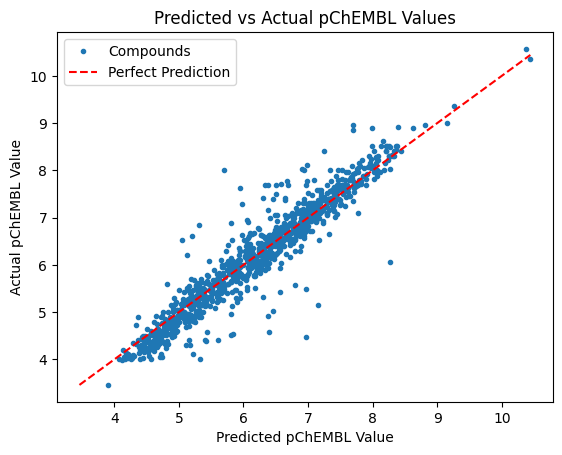

In [23]:


plt.plot(final_preds, y_test, '.', label="Compounds" )

min_val = min(min(y_test), min(final_preds))
max_val = max(min(y_test), max(final_preds))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Prediction' )

plt.xlabel("Predicted pChEMBL Value")
plt.ylabel("Actual pChEMBL Value")
plt.title("Predicted vs Actual pChEMBL Values")
plt.legend()

plt.show()

In [26]:
np.corrcoef(y_test, final_preds)

array([[1.        , 0.94752216],
       [0.94752216, 1.        ]])

## Part 8: SAVE MODEL

In [ ]:
joblib.dump(model, "best_MODEL.PARP")
print("✅ Model saved as best_MODEL.PARP")

## Part 9: Predicting Bioactivity and Virtual Screening


### 9.1 Preparing External Screening Libraries


* Data cleaning of test sets
* Descriptor alignment with training data

### 9.2 Batch Prediction Pipelines

* High‑throughput prediction
* Ranking compounds by predicted activity
* Activity cutoffs

In [27]:
!pip install catboost
import joblib
from catboost import CatBoostRegressor # Add this import

model = joblib.load("/content/sample_data/best_MODEL (1).PARP")

In [28]:
import pandas as pd
test_df = pd.read_csv("/content/sample_data/Ligand1.csv")
test_df.head()

,Molecule_ID,Smiles
0,CHEMBL4442726 MCULE-9283864166 PubChem-145865307,CC1=CC(\\C=C\\C#N)=CC(C)=C1OC1=NC(NC2=CC(F)=C(...
1,CHEMBL5287290,FC1=CC(=CC(F)=C1CC1=CN=C(NC2=CC(Cl)=C(C=C2)C#N...
2,CHEMBL5287290,FC1=CC(=CC(F)=C1CC1=CN=C(NC2=CC(Cl)=C(C=C2)C#N...
3,CHEMBL2207595 PubChem-71461474,CC1=CC(C)=C(NC2=NC(NCCNC3=NC(NC4=CC=C(C=C4)C#N...
4,CHEMBL4227581 PubChem-134817112,CC1=CC(\\C=C\\C#N)=CC(C)=C1OC1=CC(NC2=CC=C(C=C...


In [29]:
test_df.columns

Index(['Molecule_ID', 'Smiles'], dtype='object')

In [ ]:
pip install rdkit

In [30]:
# ===========================
# EXAMPLE 9A: LOAD & CLEAN TEST DATA
# ===========================

# Load test dataset
#test_df = pd.read_csv("/content/sample_data/Accacia_lib.csv")
from rdkit import Chem
# Defensive column selection
required_cols = ["Smiles"]
test_df = test_df[required_cols + [c for c in test_df.columns if c not in required_cols]]

# Track initial size
initial_test_rows = test_df.shape[0]

# Drop missing SMILES
test_df = test_df.dropna(subset=["Smiles"]).reset_index(drop=True)

# Ensure correct data type and normalize
test_df["Smiles"] = test_df["Smiles"].astype(str).str.strip()

# Remove duplicate SMILES
test_df = test_df.drop_duplicates(subset=["Smiles"]).reset_index(drop=True)

# Validate SMILES with RDKit
def is_valid_smiles(smi):
    return Chem.MolFromSmiles(smi) is not None

test_df["valid_smiles"] = test_df["Smiles"].apply(is_valid_smiles)
test_df = test_df[test_df["valid_smiles"]].drop(columns="valid_smiles").reset_index(drop=True)

# Report cleaning summary
print(
    f"Test dataset cleaned: "
    f"{initial_test_rows - test_df.shape[0]} rows removed, "
    f"{test_df.shape[0]} valid compounds remaining."
)

Test dataset cleaned: 50 rows removed, 129 valid compounds remaining.


In [31]:
# ===========================
# EXAMPLE 9B: PREDICTION & ACTIVITY SUMMARY
# ===========================

# Include necessary imports and function definitions here to ensure they are available
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem
from rdkit.Avalon import pyAvalonTools
import numpy as np
from sklearn.preprocessing import StandardScaler # Ensure StandardScaler is imported if not already

# Function to convert SMILES to RDKit molecule objects
def smiles_to_mols(smiles_list):
    """
    Convert SMILES strings to RDKit molecule objects.
    Ignore invalid SMILES.
    """
    mols = []       # List to store valid molecules
    valid_idx = []  # Index of valid molecules
    for i, smi in enumerate(smiles_list):
        mol = Chem.MolFromSmiles(smi)  # Convert SMILES to molecule
        if mol:  # Only keep valid molecules
            mols.append(mol)
            valid_idx.append(i)
    return mols, valid_idx

# Function to calculate molecular fingerprints
def calculate_fingerprints(df, smiles_col='Smiles', method='ecfp', radius=2, nBits=1024):
    """
    Compute molecular fingerprints (ECFP or Avalon) for all molecules.
    Fingerprints are numeric representations of molecular structure.
    """
    smiles_list = df[smiles_col]
    mols, valid_idx = smiles_to_mols(smiles_list)
    fingerprints = []

    for mol in mols:
        # ECFP (Morgan) fingerprint
        if method == 'ecfp':
            fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits)
        # Avalon fingerprint
        elif method == 'avalon':
            fp = pyAvalonTools.GetAvalonFP(mol, nBits=nBits)
        else:
            raise ValueError("Method must be 'ecfp' or 'avalon'")

        # Convert fingerprint to numeric array
        fp_np = np.zeros((nBits,), dtype=np.uint8)
        DataStructs.ConvertToNumpyArray(fp, fp_np)
        fingerprints.append(fp_np)

    # Create DataFrame for fingerprints
    prefix = method.upper()
    fp_df = pd.DataFrame(fingerprints, columns=[f'{prefix}_{i}' for i in range(nBits)])
    fp_df.index = valid_idx

    # Keep only valid molecules
    df_valid = df.iloc[valid_idx].reset_index(drop=True)
    fp_df = fp_df.reset_index(drop=True)

    # Combine original data and fingerprint features
    return pd.concat([df_valid, fp_df], axis=1)

# Generate predictions
test_df_with_ecfp = calculate_fingerprints(test_df, smiles_col='Smiles', method='ecfp', radius=2, nBits=1024)
PARP_X = test_df_with_ecfp.drop(columns=['Molecule_ID','Smiles'])
PARP_X_aligned =  PARP_X.reindex(columns=X_train1.columns, fill_value=0)
PARP_X_aligned_std = StandardScaler().fit_transform(PARP_X_aligned)
test_df['Predictions'] = model.predict(PARP_X_aligned_std)

[09:28:57] DEPRECATION WARNING: please use MorganGenerator
[09:28:57] DEPRECATION WARNING: please use MorganGenerator
[09:28:57] DEPRECATION WARNING: please use MorganGenerator
[09:28:57] DEPRECATION WARNING: please use MorganGenerator
[09:28:57] DEPRECATION WARNING: please use MorganGenerator
[09:28:57] DEPRECATION WARNING: please use MorganGenerator
[09:28:57] DEPRECATION WARNING: please use MorganGenerator
[09:28:57] DEPRECATION WARNING: please use MorganGenerator
[09:28:57] DEPRECATION WARNING: please use MorganGenerator
[09:28:57] DEPRECATION WARNING: please use MorganGenerator
[09:28:57] DEPRECATION WARNING: please use MorganGenerator
[09:28:57] DEPRECATION WARNING: please use MorganGenerator
[09:28:57] DEPRECATION WARNING: please use MorganGenerator
[09:28:57] DEPRECATION WARNING: please use MorganGenerator
[09:28:57] DEPRECATION WARNING: please use MorganGenerator
[09:28:57] DEPRECATION WARNING: please use MorganGenerator
[09:28:57] DEPRECATION WARNING: please use MorganGenerat

In [32]:
test_df

,Smiles,Molecule_ID,Predictions
0,CC1=CC(\\C=C\\C#N)=CC(C)=C1OC1=NC(NC2=CC(F)=C(...,CHEMBL4442726 MCULE-9283864166 PubChem-145865307,6.200527
1,FC1=CC(=CC(F)=C1CC1=CN=C(NC2=CC(Cl)=C(C=C2)C#N...,CHEMBL5287290,5.850557
2,CC1=CC(C)=C(NC2=NC(NCCNC3=NC(NC4=CC=C(C=C4)C#N...,CHEMBL2207595 PubChem-71461474,5.724563
3,CC1=CC(\\C=C\\C#N)=CC(C)=C1OC1=CC(NC2=CC=C(C=C...,CHEMBL4227581 PubChem-134817112,5.662475
4,CC1=CC(C)=C(NC2=NC(NCCCNC3=NC(NC4=CC=C(C=C4)C#...,CHEMBL2207878 PubChem-71463224,5.716725
...,...,...,...
124,COC1=NOC(=C1)C(=O)NC1(COC1)C(=O)C[C@H](C)C1=C(...,PubChem-159536921,5.370676
125,COCC1=C(C(=O)NCC2=CN=CC=C2)C(NC2=C(C)C=C(\\C=C...,PubChem-25100065,5.992299
126,CCOC(=O)CN(C)C(=O)C1=CN=C(NC2=CC=C(C=C2)C#N)N=...,PubChem-24762941,5.942415
127,CC1=CC(\\C=C\\C#N)=CC(C)=C1NC1=NC(NC2=CC=C(C=C...,PubChem-154043899,5.891411


In [34]:
# EXAMPLE 9C: Classify activity
threshold = 6.0
test_df["Activity"] = (test_df["Predictions"] >= threshold).astype(int)

# Summary report
num_active = test_df["Activity"].sum()
num_total = len(test_df)
print(f"✅ Activity Summary (Threshold = {threshold}):")
print(f"Total molecules evaluated: {num_total}")
print(f"Predicted active molecules: {num_active}")
print(f"Predicted inactive molecules: {num_total - num_active}")
print(f"Percentage active: {num_active / num_total * 100:.2f}%")


✅ Activity Summary (Threshold = 6.0):
Total molecules evaluated: 129
Predicted active molecules: 39
Predicted inactive molecules: 90
Percentage active: 30.23%


In [35]:
test_df

,Smiles,Molecule_ID,Predictions,Activity
0,CC1=CC(\\C=C\\C#N)=CC(C)=C1OC1=NC(NC2=CC(F)=C(...,CHEMBL4442726 MCULE-9283864166 PubChem-145865307,6.200527,1
1,FC1=CC(=CC(F)=C1CC1=CN=C(NC2=CC(Cl)=C(C=C2)C#N...,CHEMBL5287290,5.850557,0
2,CC1=CC(C)=C(NC2=NC(NCCNC3=NC(NC4=CC=C(C=C4)C#N...,CHEMBL2207595 PubChem-71461474,5.724563,0
3,CC1=CC(\\C=C\\C#N)=CC(C)=C1OC1=CC(NC2=CC=C(C=C...,CHEMBL4227581 PubChem-134817112,5.662475,0
4,CC1=CC(C)=C(NC2=NC(NCCCNC3=NC(NC4=CC=C(C=C4)C#...,CHEMBL2207878 PubChem-71463224,5.716725,0
...,...,...,...,...
124,COC1=NOC(=C1)C(=O)NC1(COC1)C(=O)C[C@H](C)C1=C(...,PubChem-159536921,5.370676,0
125,COCC1=C(C(=O)NCC2=CN=CC=C2)C(NC2=C(C)C=C(\\C=C...,PubChem-25100065,5.992299,0
126,CCOC(=O)CN(C)C(=O)C1=CN=C(NC2=CC=C(C=C2)C#N)N=...,PubChem-24762941,5.942415,0
127,CC1=CC(\\C=C\\C#N)=CC(C)=C1NC1=NC(NC2=CC=C(C=C...,PubChem-154043899,5.891411,0


## Part 10: Further Applications: Lipinski Filter (Drug Likeness)

In [36]:
#EXAMPLE 10A: Lipinski Filtering

from rdkit.Chem import Descriptors

# Compute molecular descriptors

def safe_mol(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return mol if mol else None

test_df["Mol"] = test_df["Smiles"].apply(safe_mol)
test_df = test_df[test_df["Mol"].notnull()]

test_df["Mol"] = test_df["Smiles"].apply(lambda x: Chem.MolFromSmiles(x))
test_df['MolWt'] = test_df['Mol'].apply(Descriptors.MolWt)
test_df['LogP'] = test_df['Mol'].apply(Descriptors.MolLogP)
test_df['nHA'] = test_df['Mol'].apply(Descriptors.NumHAcceptors)
test_df['nHD'] = test_df['Mol'].apply(Descriptors.NumHDonors)

# Apply Lipinski rule
def calculate_lipinski(row):
    if row['MolWt'] > 500 or row['LogP'] > 5 or row['nHA'] > 10 or row['nHD'] > 5:
        return 0
    else:
        return 1

Choice_Compounds = test_df[test_df["Activity"] == 1].copy()
Choice_Compounds["Lipinski"] = Choice_Compounds.apply(calculate_lipinski, axis=1)
lipinski_pass = Choice_Compounds[Choice_Compounds["Lipinski"] == 1]


In [37]:
lipinski_pass

,Smiles,Molecule_ID,Predictions,Activity,Mol,MolWt,LogP,nHA,nHD,Lipinski
9,CC1=CC(\\C=C\\C#N)=CC(C)=C1OC1=C2COCC2=NC(NC2=...,CHEMBL5281981,6.432428,1,<rdkit.Chem.rdchem.Mol object at 0x7bae4056e180>,410.437,4.46300,8,1,1
12,CC1=CC(\\C=C\\C#N)=CC(C)=C1OC1=C2NC=CC2=NC(NC2...,CHEMBL5272980,6.015831,1,<rdkit.Chem.rdchem.Mol object at 0x7bae4056e2d0>,407.437,4.91410,7,2,1
20,CON(C)CC1=CC(NC2=C(C)C=C(\\C=C\\C#N)C=C2C)=NC(...,PubChem-24991621,6.067018,1,<rdkit.Chem.rdchem.Mol object at 0x7bae4056e650>,439.523,4.98230,8,2,1
22,CN(CCO)C(=O)C1=CN=C(NC2=CC=C(C=C2)C#N)N=C1NC1=...,PubChem-24762939,6.252220,1,<rdkit.Chem.rdchem.Mol object at 0x7bae4056e730>,467.533,4.05340,8,3,1
31,COC(=O)CN1C=NC2=C1N=C(NC1=CC=C(C=C1)C#N)N=C2NC...,PubChem-58774701,6.042252,1,<rdkit.Chem.rdchem.Mol object at 0x7bae4056eb20>,494.515,4.21198,10,2,1
33,CC1=CC(\\C=C\\C#N)=CC(C)=C1NC1=NC(NC2=CC=C(C=C...,PubChem-53372474,6.119192,1,<rdkit.Chem.rdchem.Mol object at 0x7bae4056ec00>,366.428,4.98910,6,2,1
39,CC1=CC(\\C=C\\C#N)=CC(C)=C1NC1=NC(NC2=CC=C(C=C...,PubChem-49770686,6.011076,1,<rdkit.Chem.rdchem.Mol object at 0x7bae4056eea0>,439.479,4.58440,8,3,1
45,COC1=CC(\\C=C\\C#N)=CC(C)=C1NC1=NC(NC2=CC=C(C=...,PubChem-72826122,6.021626,1,<rdkit.Chem.rdchem.Mol object at 0x7bae4056f140>,422.452,4.56558,8,3,1
100,COCCNCC1=CC(NC2=C(C)C=C(\\C=C\\C#N)C=C2C)=NC(N...,PubChem-74381480,6.104150,1,<rdkit.Chem.rdchem.Mol object at 0x7bae405dc9e0>,453.550,4.72510,8,3,1
105,CC1=CC(\\C=C\\C#N)=CC(C)=C1N1C(=O)NC2=CN=C(NC3...,PubChem-166513923,6.041188,1,<rdkit.Chem.rdchem.Mol object at 0x7bae405dcc10>,407.437,3.87770,6,2,1


In [38]:
#EXAMPLE 10B: Drop Unnessary Columns and save output

Lipinski_Pass_Compounds= lipinski_pass.drop(columns=['Mol','MolWt', 'LogP', 'nHA', 'nHD'])
Lipinski_Pass_Compounds.to_csv("PARP_lipinski_pass_6.0b_CPDS.csv", index=False)
print("✅ Saved Lipinski-passing compounds")

✅ Saved Lipinski-passing compounds
